In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch
import pickle
import torch.multiprocessing as mp
from environment import CarEnvironment
from worker import worker
from model import DQN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
mp.set_start_method('spawn', force=True)

if __name__ == '__main__':

  # CPU Memory Sharing
  episode_duration = mp.Manager().list()
  rewards_per_episode = mp.Manager().list()
  average_episode_loss = mp.Manager().list()
  statistic_lock = mp.Lock()

  episodes = 100
  C = 5

  env = gym.make('CarRacing-v2', lap_complete_percent=0.95, continuous=False)
  n_actions = env.action_space
  agent = DQN(n_actions)

  train_per_episode = 200
  num_processes = max(int(mp.cpu_count() * 0.8) - 1, 1)
  processes = []
  end_episodes = 0

  print_count = 0
  save_count = 0
  copy_count = 0

  while len(processes) < min(episodes, num_processes):
    p = mp.Process(target=worker, args=(agent, episode_duration, rewards_per_episode, average_episode_loss, statistic_lock))
    p.start()
    processes.append(p)

  while end_episodes < episodes:

    new_episodes = 0

    for p in processes:
      if not p.is_alive():
        end_episodes += 1
        new_episodes += 1
        processes.remove(p)
        if len(processes) + end_episodes < episodes:
          p = mp.Process(target=worker, args=(agent, episode_duration, rewards_per_episode, average_episode_loss, statistic_lock))
          p.start()
          processes.append(p)
          
    agent._memory.load()
    for i in range(new_episodes * train_per_episode):
      agent.train()

    if end_episodes // 10 > print_count:
      print_count = end_episodes // 10
      print(f"{end_episodes} episodes done")
      print(f"{agent.training_count} training steps done")

    if end_episodes // 10 > save_count:
      save_count = end_episodes // 10
      agent.save_model(end_episodes)
      with statistic_lock:
        with open('statistics.pkl', 'wb') as f:
          pickle.dump((list(episode_duration), list(rewards_per_episode), list(average_episode_loss)), f)

    if end_episodes // C > copy_count:
      copy_count = end_episodes // C
      agent.copy_weights()

  agent.save_model(end_episodes)
  with open('statistics.pkl', 'wb') as f:
    pickle.dump((list(episode_duration), list(rewards_per_episode), list(average_episode_loss)), f)


KeyboardInterrupt: 

In [5]:
def plot_statistics(x, y, title, x_axis, y_axis):
  plt.plot(x, y)
  plt.xlabel(x_axis)
  plt.ylabel(y_axis)
  plt.title(title)
  plt.grid(True)
  plt.savefig(f'{title.replace(" ", "_")}.png')  # 공백 대신 밑줄 사용
  plt.show()
    

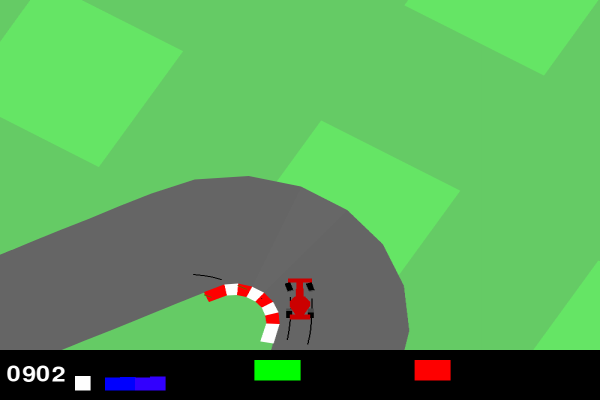

898.9328621907978


In [12]:

eval_env = gym.make('CarRacing-v2', continuous=False, render_mode='rgb_array')
eval_env = CarEnvironment(eval_env)
n_actions = eval_env.action_space
agent = DQN(n_actions)
agent.load_model(422)

frames = []
scores = 0
s, _ = eval_env.reset()

eval_env.np_random = np.random.default_rng(42)

done, ret = False, 0

from PIL import Image as PILImage
def render2img(_img): return PILImage.fromarray(_img, "RGB")
handle = display(None, display_id=True)
while not done:
  _render = eval_env.render()
  handle.update(render2img(_render))
  frames.append(_render)
  s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
  a = agent.select_action(s, evaluation_phase=True)
  discrete_action = a.item() % 5
  s_prime, r, terminated, truncated, info = eval_env.step(discrete_action)
  s = s_prime
  ret += r
  done = terminated or truncated
  if terminated:
    print(terminated)
      
scores += ret

print(scores)


In [13]:
def animate(imgs, video_name, _return=True):
  import cv2
  import os
  import string
  import random

  if video_name is None:
    video_name = ''.join(random.choice(string.ascii_letters) for i in range(18)) + '.webm'
  height, width, layers = imgs[0].shape
  fourcc = cv2.VideoWriter_fourcc(*'VP90')
  video = cv2.VideoWriter(video_name, fourcc, 10, (width, height))

  for img in imgs:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    video.write(img)
  video.release()


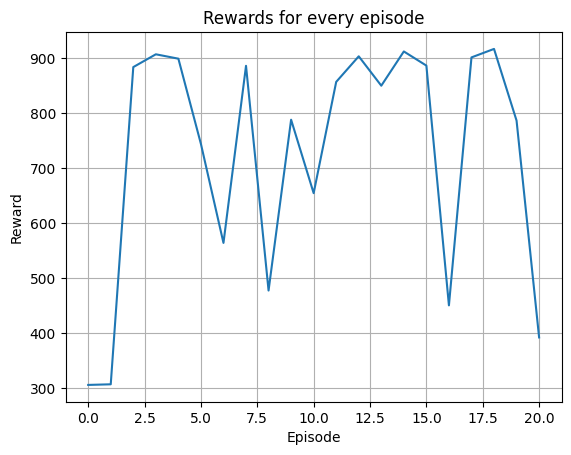

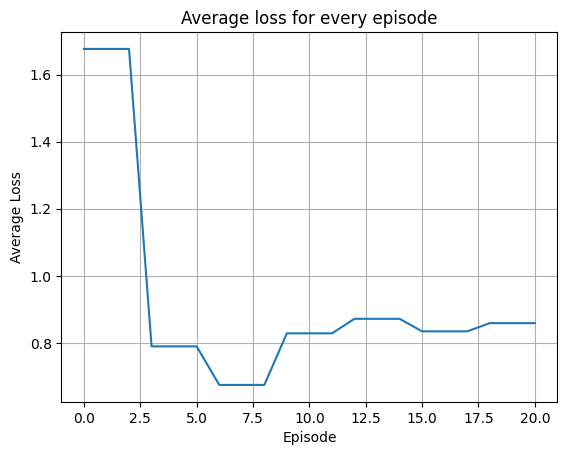

In [14]:
# animate(frames, None)

with open('statistics.pkl', 'rb') as f:
  data_tuple = pickle.load(f)

episode_duration, rewards_per_episode, average_episode_loss = data_tuple

x = [k for k in range(len(episode_duration))]

rewards_per_episode = [tensor.cpu() if tensor.is_cuda else tensor for tensor in rewards_per_episode]

plot_statistics(x, rewards_per_episode, "Rewards for every episode", "Episode", "Reward")
plot_statistics(x, average_episode_loss, "Average loss for every episode", "Episode", "Average Loss")
